In [50]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT
import src.OpticsSupport as OpticsSupport
import src.PlottingSupport as PlottingSupport
import src.STLMaker as STLMaker
import math
import scienceplots

plt.style.use(["science", "bright", "no-latex"])

cividis = mpl.colormaps["cividis"]
viridis = mpl.colormaps["viridis"]
coolwarm = mpl.colormaps["coolwarm"]

cividis.set_bad("k", 1.0)
viridis.set_bad("k", 1.0)

mpl.colors.Normalize(vmin=-1, vmax=1)

In [51]:
psf_flag = True
create_cutout = False
make_stl = False

(9466, 9466)


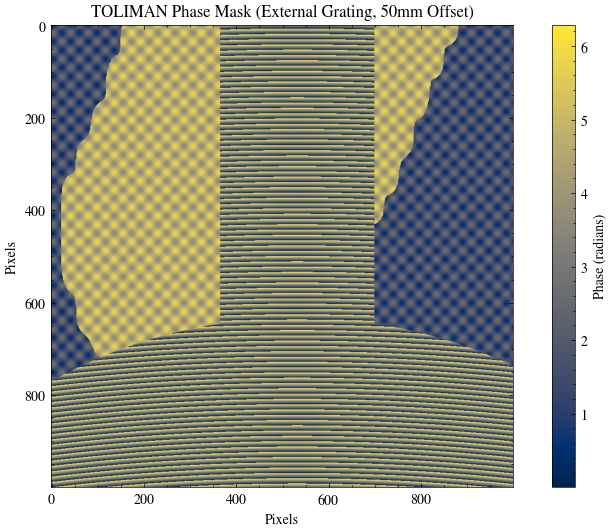

In [73]:
mask_path = "Leiden Files/June2026/15micronpix_124out_33in_5spi_142padded_squaryextgrating_50mmoffset.npy"
# mask_path = "csem Files/physical_mask_5k.npy"
phase_mask = np.load(mask_path)
print(phase_mask.shape)
plt.figure(figsize=(10,6))
#plt.imshow(phase_mask,cmap=cividis)
plt.imshow(phase_mask[3000:4000,4200:5200], cmap=cividis)
plt.colorbar(label="Phase (radians)")
plt.xlabel("Pixels")
plt.ylabel("Pixels")
plt.title("TOLIMAN Phase Mask (External Grating, 50mm Offset)")
plt.savefig("phase_mask_extern.pdf", bbox_inches="tight", dpi=1000)

In [53]:
# Aperture parameters
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_diameter = 0.125010 / ratio  # Clear aperture diameter (m)
secondary_diameter = 0.033 / ratio  # Secondary mirror diameter (m)
spider_width = 0.005 / ratio  # Spider width (m)
pix_over_125 = 5000 * (25/15)

aperture_npix = int(round(pix_over_125*(aperture_diameter/0.125)))  # Number of pixels across the aperture

# Observations wavelegths (bandpass of 530-640nm)
wavelengths = np.linspace(530e-9, 640e-9, 3)  # Wavelengths to simulate (m)

# Substrate parameters
n1 = 1  # Refractive index of free space
n2 = 1.5424  # Refractive index of Zerodur
# n2 = 1.4828 # Refractive index of ULE @589nm

# Mask
mask_path = "15micronpix_124out_33in_5spi_125padded_squaryextgrating_50mmoffset.npy"
phase_mask = np.load(mask_path) # Load the mask and convert to phase
original_mask = np.copy(phase_mask)  # Save the original mask for later

# Grating parameters
amplitude = 0#0.7*np.mean(wavelengths)/(2*(n2-n1)) #377.5e-9#421e-9 #300e-9 #375e-9  # Amplitude of the grating (m). Peak to peak amplitude of the grating etched in the glass
phase_amplitude = 0#0.7*np.pi
det_npixels = 3000 #4512 #3648  # DO NOT TOUCH
pixel_scale = dlu.arcsec2rad(0.4219)*ratio # dlu.arcsec2rad(0.375) * ratio  # 0.375 arcsec per pixel
#max_reach = 0.49035 #0.1465*np.sqrt(2) #0.406  # Max wavelength to diffract to 69.1443% of the diagonal length of the detector
#period = (1/1.78)*1e-3

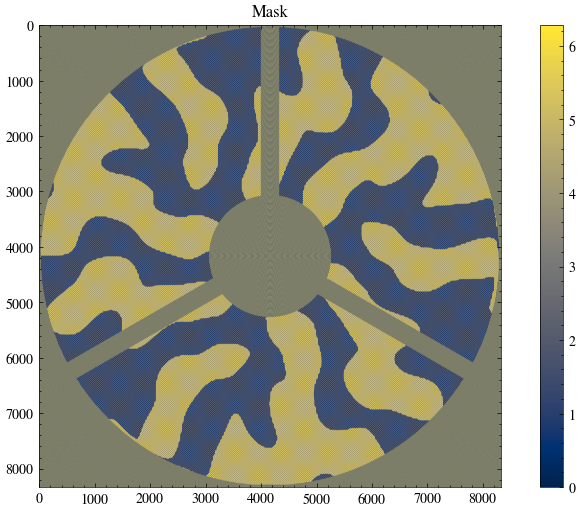

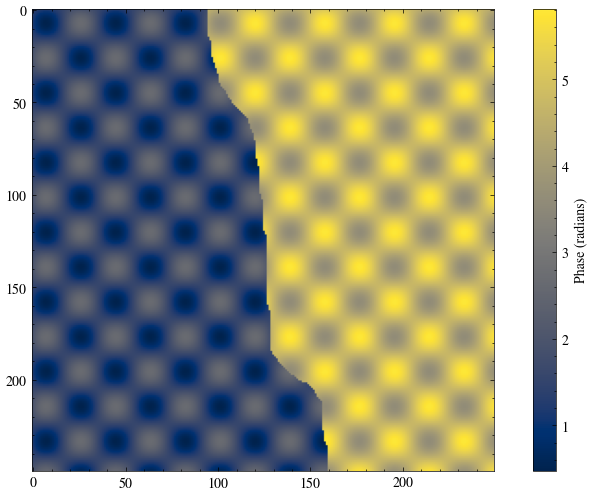

In [54]:
plt.figure(figsize=(10,6))
PlottingSupport.Plotting.printColormap(
    phase_mask, title="Mask", colorbar=True, colormap="cividis"
)
plt.figure(figsize=(10,6))
plt.imshow(phase_mask[2500:2750,2500:2750], cmap=cividis)
plt.colorbar(label="Phase (radians)")

In [55]:
wf_npixels = aperture_npix  # Number of pixels across the wavefront
peak_wavelength = np.mean(wavelengths)  # Peak wavelength of the bandpass (m)
mask = dl.Optic(phase=phase_mask)
optics = dlT.TolimanOpticalSystem(
    wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1, m1_diameter=0.125, m2_diameter=0.032,strut_width = 0.0022)
source = dl.PointSource(wavelengths, position=(0, 0))
#source = dlT.AlphaCen(n_wavels=3, separation=8, position_angle=-90)
instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
    optics, source, ratio
)
print(instrument)


Toliman(
  optics=TolimanOpticalSystem(
    wf_npixels=8334,
    diameter=0.125,
    layers={
      'aperture': TransmissiveLayer(transmission=f32[8334,8334], normalise=True),
      'pupil':
      Optic(opd=None, phase=f32[8334,8334], transmission=None, normalise=False)
    },
    psf_npixels=3000,
    oversample=1,
    psf_pixel_scale=0.4219
  ),
  source=PointSource(
    spectrum=Spectrum(wavelengths=f32[3], weights=f32[3]),
    position=f32[2],
    flux=1.0
  ),
  detector=None
)


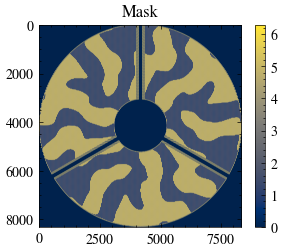

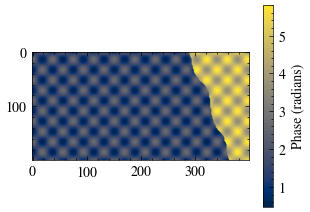

In [56]:
transmission_map = np.where(instrument.aperture.transmission, phase_mask, instrument.aperture.transmission)

PlottingSupport.Plotting.printColormap(
    transmission_map, title="Mask", colorbar=True, colormap="cividis"
)
plt.imshow(transmission_map[1700:1900,2300:2700], cmap=cividis)
plt.colorbar(label="Phase (radians)")

In [57]:
if psf_flag:
    psf = instrument.model()

300
428


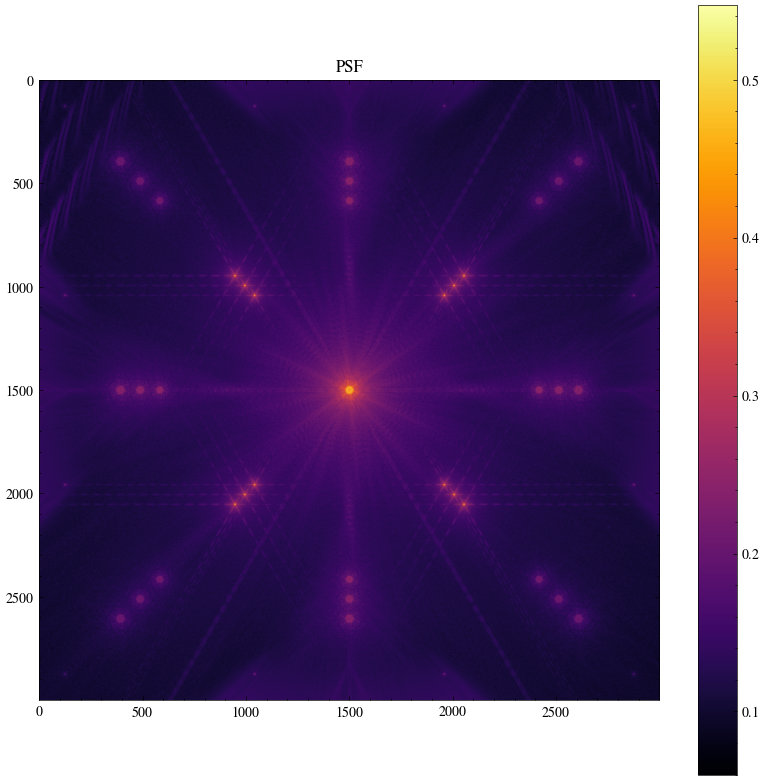

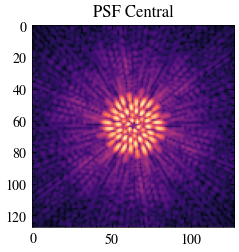

Central Flux: 66.55%


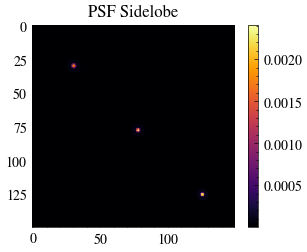

Sidelobe Flux: 23.62%


In [58]:
if psf_flag:
    r = psf.shape[0]
    c = r // 2
    s = 64
    print(r // 10)
    print(math.floor(r / 7))

    central_psf = psf[c - s : c + s, c - s : c + s]
    sidelobe_psf = psf[
        math.floor(r / 3.275) : math.floor(r / 3.275) + r // 20,
        math.floor(r / 3.275) : math.floor(r / 3.275) + r // 20,
    ]
    plt.figure(figsize=(10,10))
    PlottingSupport.Plotting.printColormap(
        psf**0.1, title="PSF", colorbar=True
    )
    plt.imsave("psf_full.pdf", psf**0.1, cmap="inferno")
    # plt.imsave("central_psf.pdf", central_psf, cmap="magma")
    # plt.imsave("sidelobe_psf.png", sidelobe_psf, cmap="inferno")
    PlottingSupport.Plotting.printColormap(
        central_psf**0.2, title="PSF Central", colorbar=False, colormap="magma"
    )
    # np.save("square_grating.npy", psf)
    plt.imsave("psf_central.pdf", central_psf**0.2, cmap="magma")
    print(f"Central Flux: {(np.sum(central_psf)/np.sum(psf))*100:.2f}%")
    PlottingSupport.Plotting.printColormap(
        sidelobe_psf, title="PSF Sidelobe", colorbar=True
    )
    print(f"Sidelobe Flux: {(np.sum(sidelobe_psf)/np.sum(psf))*4*100:.2f}%")


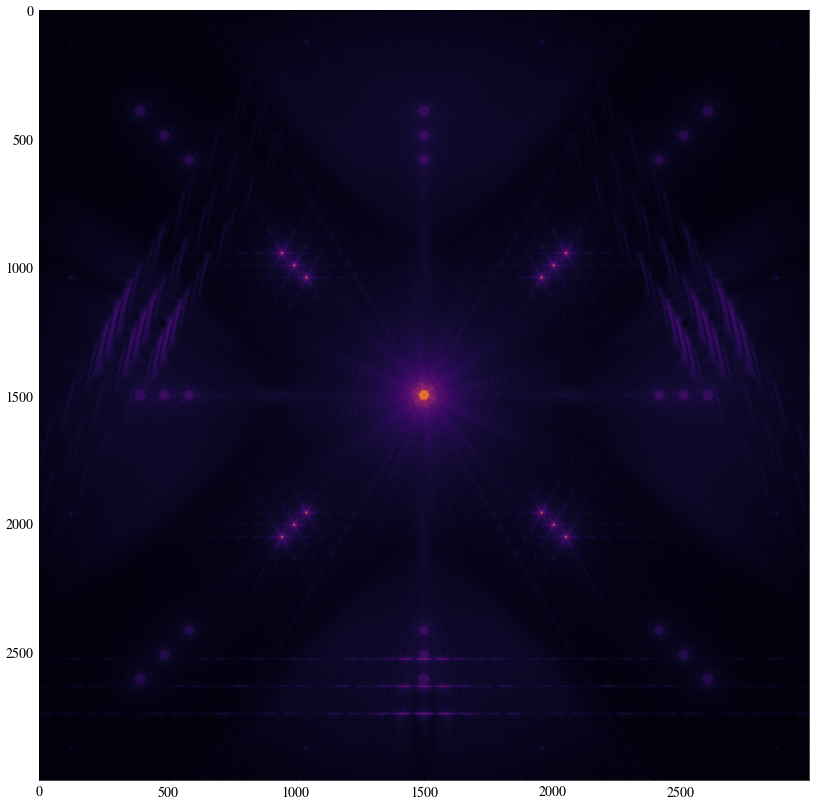

In [59]:
psf_obscured = np.load("fully_obscured.npy")
psf_linear = np.load("linear_grating.npy")
psf_circular = np.load("circular_grating.npy")
psf_squary = np.load("squary_grating_50mmoffset.npy")
psf_square = np.load("square_grating.npy")

lc_diff = (psf_linear**0.2 - psf_circular**0.2)
ol_diff = (psf_obscured - psf_linear)
oc_diff = (psf_obscured - psf_circular)
sc_diff = (psf_squary**0.2 - psf_circular**0.2)
so_diff = (psf_squary**0.2 - psf_obscured**0.2)
ss_diff = (psf_squary**0.2 - psf_square**0.2)

v = np.max(np.abs(ss_diff))
plt.figure(figsize=(10,10))
# plt.imshow(ss_diff,cmap="coolwarm", vmax=v, vmin=-v)
# plt.colorbar()
plt.imshow(psf_squary**0.2, cmap="inferno")
